#  Cat and Dog Classfication


# part _1 import libraries

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Dataset path
path =  kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")



Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.


In [2]:
train_dir = '/kaggle/input/dog-and-cat-classification-dataset/PetImages'
print("Path to dataset files:", train_dir)
os.listdir(train_dir)
cat_dir = os.path.join(train_dir, 'Cat')
dog_dir = os.path.join(train_dir, 'Dog')



Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset/PetImages


# part_2 Add Data Augmentation

In [3]:
# Add Data augmentation
train_datagen = ImageDataGenerator(
   rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    rotation_range=20
)


# Training data generator
train_gen= train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Test data generator
test_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


# part _3 CNN layer


In [4]:

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(
    train_gen,
    epochs=5,
    validation_data=test_gen
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
500/625 ━━━━━━━━━━━━━━━━━━━━ 8:01 4s/step - accuracy: 0.5278 - loss: 0.7582

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 2642s 4s/step - accuracy: 0.5644 - loss: 0.6886 - val_accuracy: 0.6164 - val_loss: 0.6605
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2637s 4s/step - accuracy: 0.6764 - loss: 0.6024 - val_accuracy: 0.7337 - val_loss: 0.5353
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2638s 4s/step - accuracy: 0.7459 - loss: 0.5185 - val_accuracy: 0.7655 - val_loss: 0.4869
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2672s 4s/step - accuracy: 0.7770 - loss: 0.4701 - val_accuracy: 0.7909 - val_loss: 0.4502
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2607s 4s/step - accuracy: 0.7961 - loss: 0.4411 - val_accuracy: 0.8071 - val_loss: 0.4243


In [5]:
#save the model
model.save('cat_and_dog.h5')
print(" Model saved successfully as 'cat_and_dog.h5'")

 Model saved successfully as 'cat_and_dog.h5'


# part_4  Plot accuracy and loss

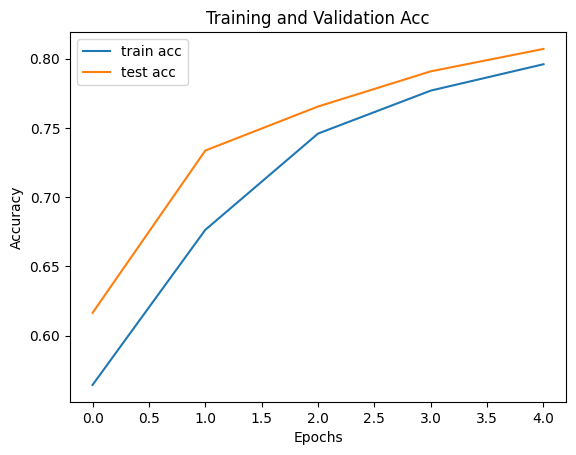

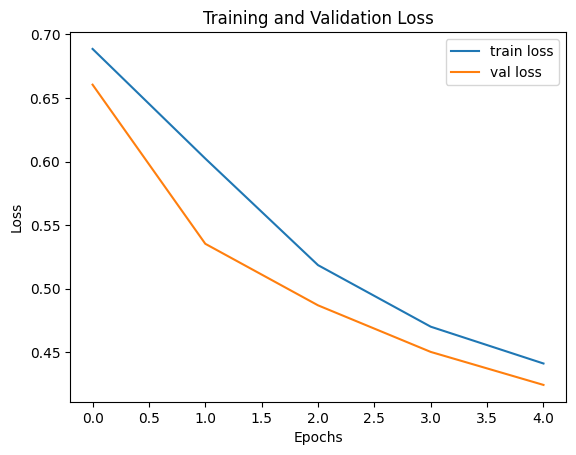

In [6]:
import matplotlib.pyplot as plt
# Plot accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='test acc')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Acc')
plt.show()

# plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

# part_5 Model Testing and Prediction

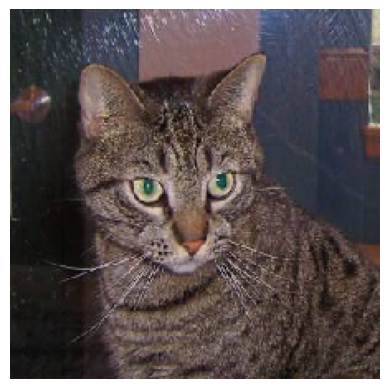

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Prediction: Cat


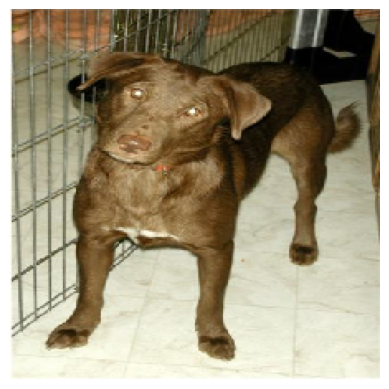

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Prediction: Dog


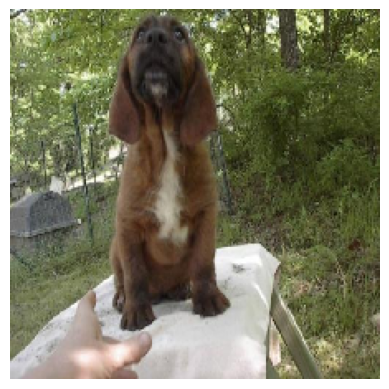

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Prediction: Dog


In [7]:
from tensorflow.keras.preprocessing import image
import os  # Import os module for path manipulation

def predict_image(image_path):
    img = image.load_img(image_path, target_size=(224, 224))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    result = model.predict(img_array)
    prediction = "Dog" if result[0][0] >= 0.5 else "Cat" # Threshold
    print("Prediction:", prediction)

# Example paths using os.path.join and existing directory variables
# You might need to check the actual filenames in your dataset.
predict_image(os.path.join(cat_dir, '1.jpg'))  # Assuming '1.jpg' exists in the Cat directory
predict_image(os.path.join(dog_dir, '1.jpg'))  # Assuming '1.jpg' exists in the Dog directoy
predict_image(os.path.join(dog_dir, '5.jpg'))  # Assuming '5.jpg' exists in the Dog directory




In [8]:
# load the model to predict new data

from tensorflow.keras.models import load_model
model = load_model('cat_and_dog.h5')
print(" Model loaded successfully!")

 Model loaded successfully!


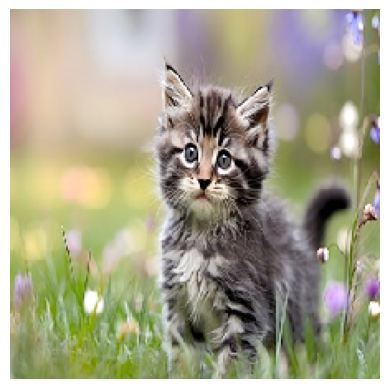

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Prediction: Cat


In [16]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img_path = '/content/images.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Dog")
else:
    print("Prediction: Cat")

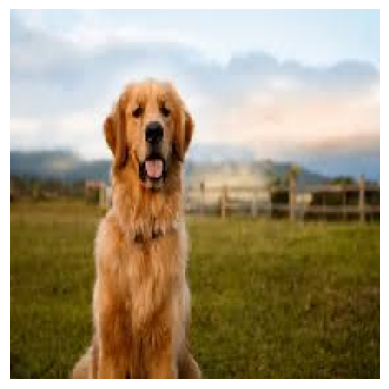

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Prediction: Dog


In [18]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img_path = '/content/images (1).jpg' # Corrected path to include the space
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Dog")
else:
    print("Prediction: Cat")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


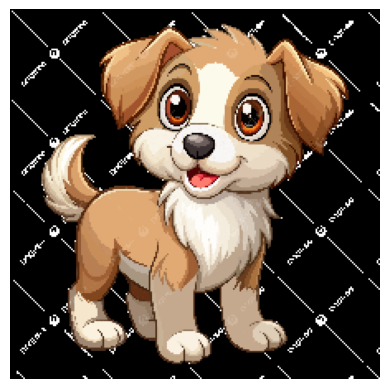

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Prediction: Dog


In [20]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img_path = '/content/images2.png' # Corrected file extension from .jpg to .png
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

plt.imshow(img)
plt.axis('off')
plt.show()

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Dog")
else:
    print("Prediction: Cat")